In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [3]:
df_raw = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

In [4]:
age_u65_cols = [
    "Deaths at age 0",
    "Deaths at age 1",
    "Deaths at age 2",
    "Deaths at age 3",
    "Deaths at age 4",
    "Deaths at age 5-9",
    "Deaths at age 10-14",
    "Deaths at age 15-19",
    "Deaths at age 20-24",
    "Deaths at age 25-29",
    "Deaths at age 30-34",
    "Deaths at age 35-39",
    "Deaths at age 40-44",
    "Deaths at age 45-49",
    "Deaths at age 50-54",
    "Deaths at age 55-59",
    "Deaths at age 60-64",
]

# 2. Todesfälle < 65 pro Zeile (Land x Ursache x Jahr) aufsummieren
df_raw["deaths_u65_row"] = df_raw[age_u65_cols].sum(axis=1)

# 3. Auf Länderebene pro Jahr aggregieren
grouped = (
    df_raw
    .groupby(["Country", "Year"])
    .agg(
        deaths_u65_total=("deaths_u65_row", "sum"),
        deaths_all_total=("Deaths at all ages", "sum")
    )
    .reset_index()
)

# 4. Anteil unter 65 berechnen
grouped["p_u65"] = grouped["deaths_u65_total"] / grouped["deaths_all_total"]

# 5. Offensichtliche Datenfehler raus (optional, wie zuvor)
grouped = grouped.dropna(subset=["p_u65"])
grouped = grouped[(grouped["p_u65"] > 0) & (grouped["p_u65"] < 0.7)]

print(grouped.head())

    Country  Year  deaths_u65_total  deaths_all_total     p_u65
0  Anguilla  2000              26.0               144  0.180556
1  Anguilla  2001              28.0               104  0.269231
2  Anguilla  2002              42.0               114  0.368421
3  Anguilla  2003              50.0               140  0.357143
4  Anguilla  2004              22.0                96  0.229167


In [5]:
year_before = 2001
year_after  = 2017

df_before = grouped[grouped["Year"] == year_before][["Country", "p_u65"]].rename(columns={"p_u65": f"p_u65_{year_before}"})
df_after  = grouped[grouped["Year"] == year_after][["Country", "p_u65"]].rename(columns={"p_u65": f"p_u65_{year_after}"})

# Nur Länder, die in BEIDEN Jahren vorkommen
df_pair = (
    df_before
    .merge(df_after, on="Country")
    .dropna()
)

print("Anzahl gepaarter Länder:", len(df_pair))
df_pair.head()


Anzahl gepaarter Länder: 61


,Country,p_u65_2001,p_u65_2017
0,Anguilla,0.269231,0.337209
1,Antigua and Barbuda,0.383117,0.364121
2,Argentina,0.323144,0.264715
3,Aruba,0.362473,0.250000
4,Australia,0.213428,0.178107


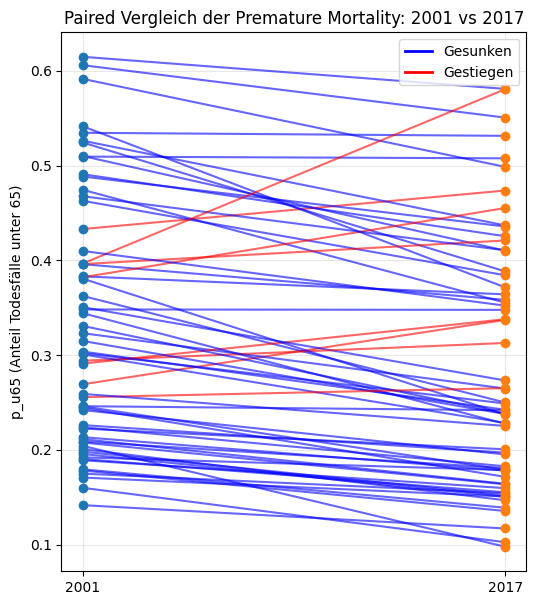

In [7]:
plt.figure(figsize=(6, 7))

for _, row in df_pair.iterrows():
    y1 = row[f"p_u65_{year_before}"]
    y2 = row[f"p_u65_{year_after}"]
    
    # Farbe je nach Entwicklung
    if y2 > y1:
        color = "red"      # schlechter geworden
    else:
        color = "blue"     # besser geworden
    
    plt.plot(
        [0, 1],
        [y1, y2],
        color=color,
        alpha=0.6,
        linewidth=1.5
    )

# Punkte für die Jahre
plt.scatter(
    np.zeros(len(df_pair)),
    df_pair[f"p_u65_{year_before}"],
    label=str(year_before),
    color="tab:blue",
    zorder=3
)

plt.scatter(
    np.ones(len(df_pair)),
    df_pair[f"p_u65_{year_after}"],
    label=str(year_after),
    color="tab:orange",
    zorder=3
)

plt.xticks([0, 1], [str(year_before), str(year_after)])
plt.ylabel("p_u65 (Anteil Todesfälle unter 65)")
plt.title(f"Paired Vergleich der Premature Mortality: {year_before} vs {year_after}")

# Custom Legende
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="blue", lw=2, label="Gesunken"),
    Line2D([0], [0], color="red", lw=2, label="Gestiegen"),
]
plt.legend(handles=legend_elements, loc="upper right")

plt.grid(alpha=0.3)
plt.show()


Nullhypothese H₀:
Der Mittelwert von p_u65 ist im Jahr 2001 und 2017 gleich.

Alternativhypothese H₁ (zweiseitig, Standard):
Der Mittelwert von p_u65 unterscheidet sich zwischen 2001 und 2017.